# Clinico-Transcriptomic Discovery of Prognostic Biomarkers and Functional Hallmarks in TCGA Breast Cancer Using Python
---
   ## Notebook 2: Exploratory Analysis and Data Normalization 

### 1. Biological Motivation

Before attempting predictive modeling or differential expression analysis, it is essential to characterize the structure of the transcriptomic dataset. RNA-sequencing experiments measure expression for tens of thousands of genes, many of which are either not expressed or exhibit minimal variation across patients.

These genes contribute little biological information while increasing computational complexity and statistical noise.

This notebook therefore addresses the following questions:

> Which genes contain sufficient expression signal to justify downstream analysis?

> Does normalization successfully stabilize the distribution of RNA-seq counts?

> Is overall gene expression sufficient to naturally separate patients according to survival status?

Answering these questions establishes whether additional supervised learning methods will be necessary for prognostic prediction.

### 2. Import Required Libraries

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Set up plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### 3. Load Curated Expression and Clinical Data

In [3]:
# Load data
counts = pd.read_csv("../data/processed/brca_counts_cleaned.csv", index_col=0)
clinical = pd.read_csv("../data/processed/brca_clinical_cleaned.csv", index_col=0)

print(f"Loaded counts matrix: {counts.shape} (Genes x Samples)")
print(f"Loaded clinical metadata: {clinical.shape} (Patients x Features)")

Loaded counts matrix: (19962, 1019) (Genes x Samples)
Loaded clinical metadata: (1019, 8) (Patients x Features)


### 4. Expression Filtering: Low-Count Gene Removal

In [4]:
print("--- Low-Count Filtering ---")

# Calculate 10% of our 1,019 patients
min_samples = int(0.10 * counts.shape[1])  # Roughly 101 samples
print(f"A gene must have >= 10 reads in at least {min_samples} patients to be kept.")

# Create a true/false mask for rows passing our condition
keep_genes_mask = (counts >= 10).sum(axis=1) >= min_samples

# Filter the matrix
counts_filtered = counts_num = counts[keep_genes_mask]

print(f"Genes remaining after low-count filtering: {counts_filtered.shape[0]}")

--- Low-Count Filtering ---
A gene must have >= 10 reads in at least 101 patients to be kept.
Genes remaining after low-count filtering: 16790


### 5. Variance Stabilization via Log Transformation

In [5]:
# Apply log2(counts + 1) transformation
counts_log = np.log2(counts_filtered + 1)

print("Data successfully transformed to log2 scale.")
print("Example raw counts:\n", counts_filtered.iloc[:3, :3])
print("\nExample log2 transformed counts:\n", counts_log.iloc[:3, :3])

Data successfully transformed to log2 scale.
Example raw counts:
                     TCGA-3C-AAAU  TCGA-3C-AALI  TCGA-3C-AALJ
gene_id                                                     
ENSG00000000003.15           651           418          1303
ENSG00000000005.6              2             2            52
ENSG00000000419.13          1872          1818          1281

Example log2 transformed counts:
                     TCGA-3C-AAAU  TCGA-3C-AALI  TCGA-3C-AALJ
gene_id                                                     
ENSG00000000003.15      9.348728      8.710806     10.348728
ENSG00000000005.6       1.584963      1.584963      5.727920
ENSG00000000419.13     10.871135     10.828930     10.324181


#### Distributional Comparison

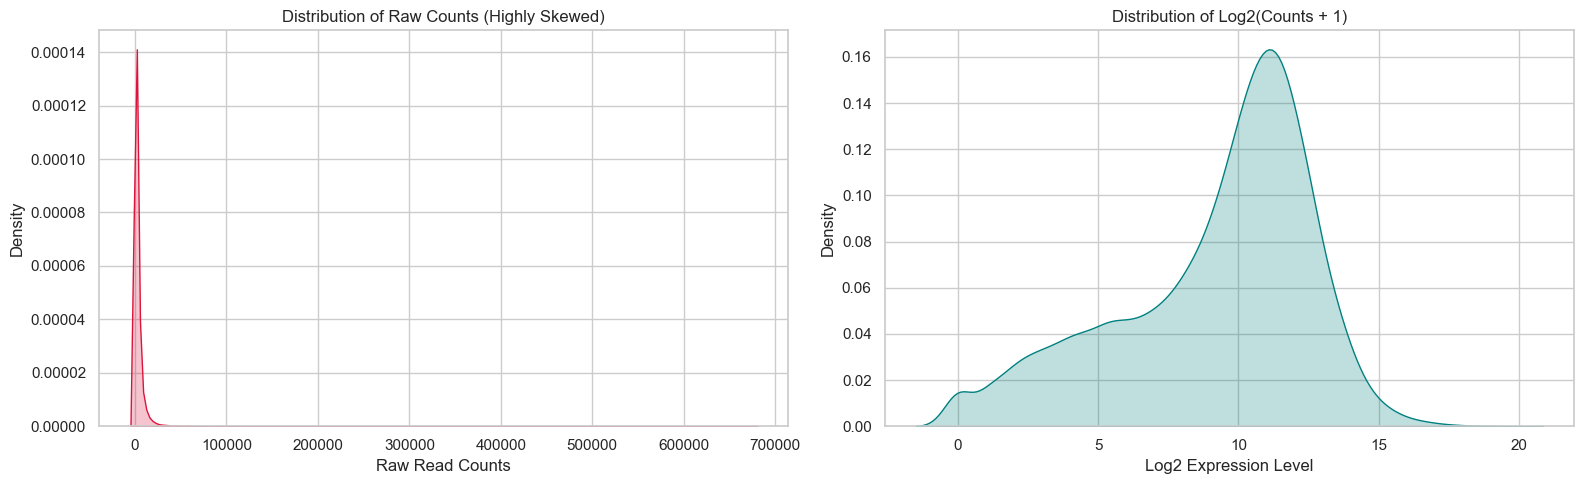

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Raw Counts (Highly skewed)
sns.kdeplot(counts_filtered.iloc[:, 0], ax=axes[0], fill=True, color="crimson")
axes[0].set_title("Distribution of Raw Counts (Highly Skewed)")
axes[0].set_xlabel("Raw Read Counts")

# Plot Log2 Counts (Bell curve-ish shape)
sns.kdeplot(counts_log.iloc[:, 0], ax=axes[1], fill=True, color="teal")
axes[1].set_title("Distribution of Log2(Counts + 1)")
axes[1].set_xlabel("Log2 Expression Level")

plt.tight_layout()
plt.show()

#### Interpretation

The transformation produces a substantially more symmetric distribution, improving suitability for multivariate analysis.

In [7]:
counts_log.to_csv("../data/processed/brca_counts_normalized_log.csv")
print("Exploratory preprocessing complete! Saved normalized expression matrix.")

Exploratory preprocessing complete! Saved normalized expression matrix.


### 6. Global Transcriptomic Structure via PCA

#### 6.1 PCA on Full Transcriptome

In [8]:
# 1. Transpose matrix so rows are patients and columns are genes
pca_input = counts_log.T

# 2. Standardize features to mean=0 and variance=1 (crucial for PCA)
scaler = StandardScaler()
pca_input_scaled = scaler.fit_transform(pca_input)

# 3. Initialize and fit PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(pca_input_scaled)

# Calculate the variance explained by the first two components
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

pca_df = pd.DataFrame({ "PC1": pca_results[:, 0], 
                        "PC2": pca_results[:, 1], 
                        "Vital_status": clinical.loc[pca_input.index, "vital_status"]
                      })


print(pca_df.head())

                     PC1        PC2 Vital_status
TCGA-3C-AAAU   20.295713 -21.635029        Alive
TCGA-3C-AALI  -76.061127   8.557198        Alive
TCGA-3C-AALJ -178.188168 -14.986227        Alive
TCGA-3C-AALK  -21.592794  -5.917271        Alive
TCGA-4H-AAAK  -26.156096 -12.867885        Alive


#### 6.2 Visualization of Cohort Structure

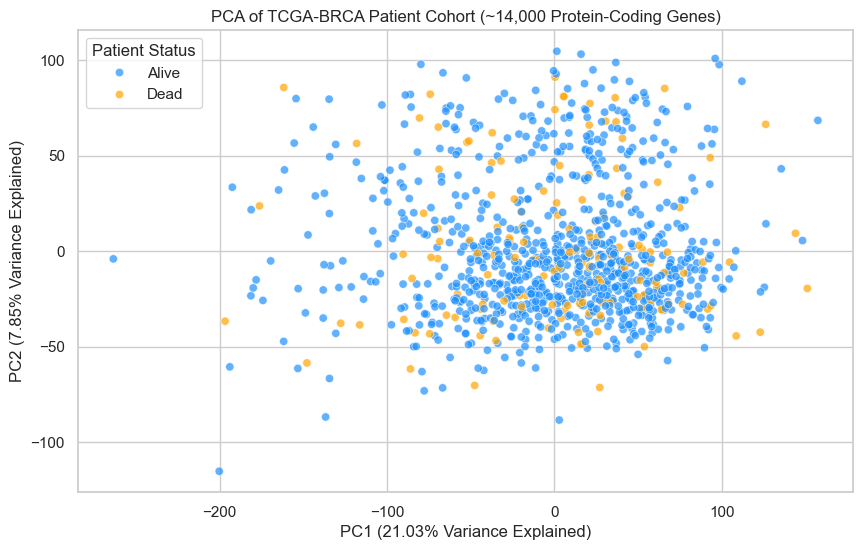

In [9]:
sns.scatterplot(
    x="PC1", y="PC2", 
    hue="Vital_status", 
    palette={"Alive": "dodgerblue", "Dead": "orange"},
    alpha=0.7, 
    data=pca_df
)

plt.title("PCA of TCGA-BRCA Patient Cohort (~14,000 Protein-Coding Genes)")
plt.xlabel(f"PC1 ({var_pc1:.2f}% Variance Explained)")
plt.ylabel(f"PC2 ({var_pc2:.2f}% Variance Explained)")
plt.legend(title="Patient Status")
plt.show()

#### Interpretation:
The first two principal components explained only a modest proportion of total variance. Visualization of patients revealed substantial overlap between individuals who were alive and those who were deceased at follow-up. No obvious clustering according to survival status was observed.

Overall transcriptomic variation appears to be driven by biological processes unrelated to survival status, including molecular subtype, immune composition, tumour purity, or technical variability.Consequently, patient outcome is unlikely to be recoverable using unsupervised dimensionality reduction alone.

### 7. PCA Using Highly Variable Genes

#### 7a. Variance-Driven Feature Selection

In [10]:
gene_variances = counts_log.var(axis=1)
top_highly_variable_genes = gene_variances.nlargest(1000).index
X_variable = counts_log.loc[top_highly_variable_genes].T

#### 7b. PCA on High-Variance Gene Space

In [11]:
scaler = StandardScaler()
X_variable_scaled = scaler.fit_transform(X_variable)

pca = PCA(n_components=2)
var_pca_results = pca.fit_transform(X_variable_scaled)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

var_pca_df = pd.DataFrame({ "PC1": var_pca_results[:, 0], 
                            "PC2": var_pca_results[:, 1], 
                            "Vital_status": clinical.loc[pca_input.index, "vital_status"]
                          })


#### 7c.Visualization of High-Variance Gene Space

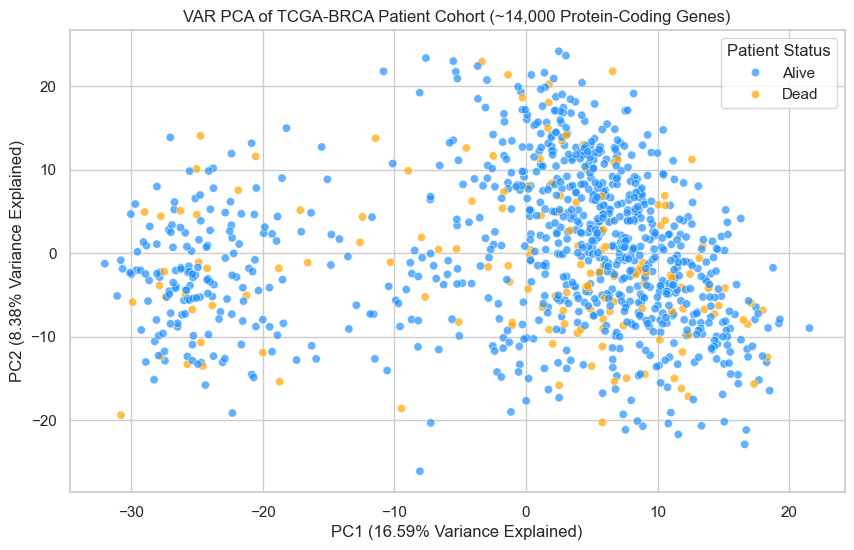

In [12]:
sns.scatterplot(
    x="PC1", y="PC2", 
    hue="Vital_status", 
    palette={"Alive": "dodgerblue", "Dead": "orange"},
    alpha=0.7, 
    data=var_pca_df
)

plt.title("VAR PCA of TCGA-BRCA Patient Cohort (~14,000 Protein-Coding Genes)")
plt.xlabel(f"PC1 ({var_pc1:.2f}% Variance Explained)")
plt.ylabel(f"PC2 ({var_pc2:.2f}% Variance Explained)")
plt.legend(title="Patient Status")
plt.show()

#### Interpretation:

Despite restricting the analysis to highly variable genes, patients remained extensively intermingled in principal component space. No visually distinct clusters corresponding to survival status emerged.

Although highly variable genes capture substantial transcriptional heterogeneity, this variation does not appear to align with overall survival. These findings suggest that survival-associated expression patterns are likely subtle and distributed across many genes rather than dominating the global variance structure.

### Notebook Summary

This notebook transformed the raw RNA-seq expression matrix into a statistically stable and biologically interpretable representation suitable for downstream analysis.

Key processing steps included:

| Step                         | Purpose                                    |
| ---------------------------- | ------------------------------------------ |
| Low-count filtering          | Remove noisy, low-abundance genes          |
| Log2 transformation          | Stabilize variance and reduce skew         |
| Standardization              | Enable PCA comparability                   |
| PCA projection               | Identify global transcriptomic structure   |
| High-variance gene selection | Focus on biologically informative features |

Key findings:
* Low-expression filtering reduced noise while preserving most expressed genes.
* Log₂ normalization substantially stabilized the distribution of RNA-seq counts.
* PCA revealed no natural separation between patients based on survival status.
* Restricting analysis to highly variable genes did not improve clustering.

The resulting analysis demonstrates that hat survival prediction will likely require supervised machine learning approaches capable of identifying complex multigene signatures rather than relying on unsupervised transcriptomic structure.